In [1]:
import ROOT
import pandas as pd
import numpy as np
import os
import sys
import ipynbname
from pathlib import Path

project_root = str(ipynbname.path().parent.parent)
sys.path.append(project_root)
project_root=Path(project_root)

from processing import SiphraAcquisition, MetadataLoader
from analysis import fit_peak_expbg

# Constants
BITS12 = 2**12
BITS9 = 2**9 # 512 typical number of bins used

# Energy emission peaks in MeV
Cs137_MeV = 0.662
Na22_MeV = [0.511, 1.275, 1.786]
Co60_MeV = [1.173, 1.332, 2,505]
Am241_MeV = 0.0595
# Background emission
K40_MeV = 1.460
Tl208_MEV = 2.614

colors = [
    ROOT.kRed + 1,
    ROOT.kBlue + 1,
    ROOT.kGreen + 2,
    ROOT.kOrange + 7,
    ROOT.kMagenta + 1,
    ROOT.kCyan + 1,
    ROOT.kViolet + 2,
    ROOT.kPink + 7,
    ROOT.kTeal + 3,
    ROOT.kAzure + 2,
    ROOT.kSpring + 5,
]
siphras = ['A', 'B']

In [2]:
files = sorted((project_root/'data/260518').glob('SUBT_*'))
acqs = [SiphraAcquisition(file) for file in files]
#print(acqs)
Abackground = acqs[12]
Bbackground = acqs[25]
backgrounds = [acqs[12], acqs[25]]
calibrations = [acqs[0], acqs[13]]
Aacqs = acqs[:12]
Bacqs = acqs[13:25]
acqs = [acqs[1:12], acqs[14:25]]
#print(backgrounds)
#print(calibrations)
#print(acqs)

In [4]:
# Create histograms for background and each distance for both siphras. Create background subtracted histograms. 
hists = {}
distances_cm = list(range(3, 14))
for i in range(2):
    siphra = siphras[i]
    bg = backgrounds[i]

    #Background
    hist_bg = ROOT.TH1F(f"{siphra}_Background", "", BITS12, 0 , BITS12)
    hist_bg.Fill(bg['s']/len(bg.active_chs))
    hist_bg.GetXaxis().SetTitle("ADC channel number")
    hist_bg.GetYaxis().SetTitle(r"Normalized counts")
    hists[f"{siphra}_Background"] = hist_bg
    
    for sgnl, distance in zip(acqs[i], distances_cm):

        # Distance to B = 16 - distance to A
        if siphra == 'B':
            distance = 16-distance
        filepath = sgnl.filepath.stem
        print(distance)

        # Signal
        hist_sgnl = ROOT.TH1F(f"{siphra}_{distance}cm_signal", "", BITS12, 0, BITS12)
        hist_sgnl.Fill(sgnl['s']/len(sgnl.active_chs))      
        hist_sgnl.Scale(bg.exposure/sgnl.exposure)
        
        # Clean spectrum
        hist_clean = hist_sgnl.Clone(f"{siphra}_{distance}cm_clean")
        hist_clean.Add(hist_bg, -1)
        
        for hist in [hist_sgnl, hist_clean]:
            hist.GetXaxis().SetTitle("ADC channel number")
            hist.GetYaxis().SetTitle(r"Normalized counts")
            
        hists[f"{siphra}_{distance}cm_signal"] = hist_sgnl      
        hists[f"{siphra}_{distance}cm_clean"] = hist_clean

        
        del hist_sgnl
        del hist_clean
    del hist_bg

3
4
5
6
7
8
9
10
11
12
13
13
12
11
10
9
8
7
6
5
4
3
{'A_Background': <cppyy.gbl.TH1F object at 0x58e029f9c790>, 'A_3cm_signal': <cppyy.gbl.TH1F object at 0x58e02a275c10>, 'A_3cm_clean': <cppyy.gbl.TH1F object at 0x58e02a289ae0>, 'A_4cm_signal': <cppyy.gbl.TH1F object at 0x58e02a248810>, 'A_4cm_clean': <cppyy.gbl.TH1F object at 0x58e02a1af750>, 'A_5cm_signal': <cppyy.gbl.TH1F object at 0x58e029fb41c0>, 'A_5cm_clean': <cppyy.gbl.TH1F object at 0x58e029fb7060>, 'A_6cm_signal': <cppyy.gbl.TH1F object at 0x58e02421cd90>, 'A_6cm_clean': <cppyy.gbl.TH1F object at 0x58e024e7c390>, 'A_7cm_signal': <cppyy.gbl.TH1F object at 0x58e02952cc40>, 'A_7cm_clean': <cppyy.gbl.TH1F object at 0x58e0275d7b90>, 'A_8cm_signal': <cppyy.gbl.TH1F object at 0x58e02a55bc30>, 'A_8cm_clean': <cppyy.gbl.TH1F object at 0x58e02a277050>, 'A_9cm_signal': <cppyy.gbl.TH1F object at 0x58e02abf22e0>, 'A_9cm_clean': <cppyy.gbl.TH1F object at 0x58e02a24b0a0>, 'A_10cm_signal': <cppyy.gbl.TH1F object at 0x58e02974df70>, 'A_10cm_c

In [5]:
#Draw one histogram for each distance + siphra combination

if ROOT.gROOT.FindObject('cv1'):
    ROOT.gROOT.FindObject('cv1').Close()

Yinit = 0.82 # For stat boxes

cv1 = ROOT.TCanvas('cv1', 'cv1', 4800, 2400)
cv1.Divide(5, 5)

ROOT.gStyle.SetOptStat(11)
ROOT.gStyle.SetStatFontSize(0.03)
ROOT.gStyle.SetStatW(0.16)

lgds = [ROOT.TLegend(0.48, 0.61, 0.75, 0.83) for _ in range(22)]

for i, siphra in enumerate(siphras):  
    for idx, distance in enumerate(distances_cm):
        lg = lgds[11*i + idx]
        cv1.cd(11*i+idx+1)
        cv1.cd(11*i+idx+1).SetLogy()
        
        bg = hists[f"{siphra}_Background"] 
        sgnl = hists[f"{siphra}_{distance}cm_signal"]         
        clean = hists[f"{siphra}_{distance}cm_clean"] 
        
        lg.AddEntry(sgnl, f"SIPHRA {siphra} {distance} cm")
        lg.AddEntry(bg, "Background")
        lg.AddEntry(clean, f" SIPHRA {siphra} {distance} cm, BG subtracted")
        
        sgnl.SetLineColor(colors[0])
        bg.SetLineColor(colors[1])
        clean.SetLineColor(colors[2])
        sgnl.SetTitle(str(distance))

        # Drw histograms
        bg.Draw("hist")
        sgnl.Draw("sames hist")
        clean.Draw("sames hist")
        ROOT.gPad.Update()
        lg.Draw()
        cv1.Draw()
    


In [22]:
#Plot all the subtracted histogram spectra in one plot.

if ROOT.gROOT.FindObject('cv2'):
    ROOT.gROOT.FindObject('cv2').Close()

Yinit = 0.82 # For stat boxes

cv2 = ROOT.TCanvas('cv2', 'cv2', 2400, 1200)
cv2.Divide(2,1)

ROOT.gStyle.SetOptStat(11)
ROOT.gStyle.SetStatFontSize(0.03)
ROOT.gStyle.SetStatW(0.16)

lgds = [ROOT.TLegend(0.48, 0.61, 0.75, 0.83) for _ in range(2)]

for i, (siphra, lg) in enumerate(zip(siphras, lgds)):
    cv2.cd(i+1)
    cv2.cd(i+1).SetLogy()
    

    for idx, (distance) in enumerate(distances_cm):   
        
        clean = hists[f"{siphra}_{distance}cm_clean"] 
        lg.AddEntry(clean, f"Bg subtracted {distance} cm SIPHRA {siphra}")
        clean.SetLineColor(colors[idx])
        if idx ==0:
            clean.Draw("hist")
        else:
            clean.Draw("sames hist")
        ROOT.gPad.Update()
        
    lg.Draw()   
    cv2.Draw()

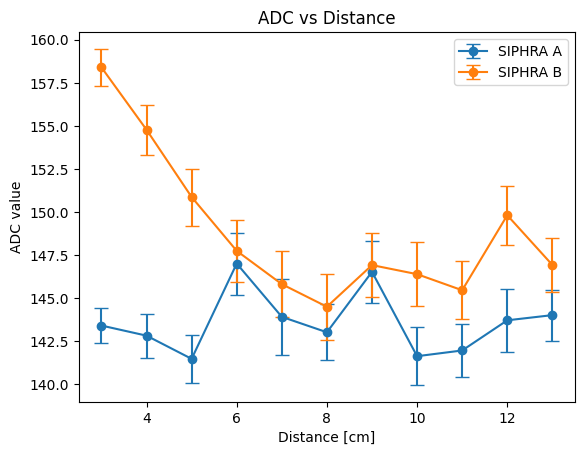

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      107.673
NDf                       =          112
Edm                       =  7.23791e-06
NCalls                    =           59
Constant                  =      180.136   +/-   6.2789      
Mean                      =      143.418   +/-   0.997448    
Sigma                     =      25.5667   +/-   1.00331      	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      114.787
NDf                       =          112
Edm                       =  7.16879e-06
NCalls                    =           61
Constant                  =      140.779   +/-   5.99521     
Mean                      =      142.831   +/-   1.26928     
Sigma                     =       26.558   +/-   1.29704      	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      121.554
NDf                   

In [21]:
#Plot the mean ADC value of the photopeak for each SIPHRA and distance. Include error bars.
#TODO: show as a percentage deviation from total mean? Like in Mozsis plot?

import matplotlib.pyplot as plt

means_list = []
error_list = []
for i, siphra in enumerate(siphras):
    means = []
    errors = []
    for j, distance in enumerate(distances_cm):
        hist = hists[f"{siphra}_{distance}cm_clean"] 
        gaus_fit = ROOT.TF1("gaus_fit", "gaus", 85, 200)
        hist.Fit(gaus_fit, "R+S")
        
        mean = gaus_fit.GetParameter(1)
        error = gaus_fit.GetParError(1)
        means.append(mean)
        errors.append(error)
    means_list.append(means)
    error_list.append(errors)

for i, (means, errors, siphra) in enumerate(zip(means_list, error_list, siphras)):
    plt.errorbar(
        distances_cm,
        means,
        yerr=errors,
        fmt='o-',        # 'o' means scatter points
        capsize=5,      # little caps on error bars
        label = f"SIPHRA {siphra}"
        #ecolor='black'
    )


plt.legend()
plt.xlabel("Distance [cm]")
plt.ylabel("ADC value")
plt.title("ADC vs Distance")

plt.show()
        
        